# MODELO LSTM:

In [ ]:
# Importar librerías para manipulación de datos
import pandas as pd  # Para trabajar con tablas y dataframes
import numpy as np  # Para trabajar con arrays y operaciones numéricas

# Importar librerías para visualización
import matplotlib.pyplot as plt  # Para representar gráficos

# Importar escalador robusto
from sklearn.preprocessing import RobustScaler  # Para escalar la serie con menor sensibilidad a outliers

# Importar métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error  # Para calcular MAE y RMSE

# Importar utilidades para generar combinaciones y muestrearlas aleatoriamente
from itertools import product  # Para construir todas las combinaciones posibles de la grilla
import random  # Para seleccionar una muestra aleatoria de combinaciones

# Importar TensorFlow / Keras para construir la red neuronal
import tensorflow as tf  # Framework principal de deep learning
from tensorflow.keras.models import Sequential  # Modelo secuencial de Keras
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout  # Capas del modelo LSTM
from tensorflow.keras.callbacks import EarlyStopping  # Callback para detener el entrenamiento si no mejora

# Fijar semillas para mejorar la reproducibilidad
np.random.seed(42)  # Semilla de NumPy
random.seed(42)  # Semilla del módulo random
tf.random.set_seed(42)  # Semilla de TensorFlow

# Configuración opcional de gráficos para que se vean mejor
plt.rcParams["figure.figsize"] = (12, 5)  # Tamaño por defecto de las figuras
plt.rcParams["axes.grid"] = True  # Activar cuadrícula por defecto

In [ ]:
# Cargar el archivo CSV con la serie agregada de Galicia
df = pd.read_csv("bbdd_biogas_galicia.csv")  # Ajusta el nombre si tu archivo tiene otro nombre

# Convertir la columna datetime al formato de fecha
df["datetime"] = pd.to_datetime(df["datetime"])  # Asegura que pandas interprete correctamente las fechas

# Ordenar las observaciones cronológicamente
df = df.sort_values("datetime")  # Muy importante en series temporales para respetar el orden temporal

# Resetear el índice después de ordenar
df = df.reset_index(drop=True)  # Evita conservar el índice antiguo tras la ordenación

# Seleccionar únicamente las columnas necesarias para el modelado
df_model = df[["datetime", "generacion_biogas_mwh"]].copy()  # Copia limpia con fecha y variable objetivo

# Extraer la serie como array de NumPy
serie = df_model["generacion_biogas_mwh"].values  # Variable objetivo en formato array

# Mostrar información básica de la serie
print("Número total de observaciones:", len(serie))  # Mostrar longitud de la serie
print("Fecha inicial:", df_model["datetime"].min())  # Mostrar primera fecha
print("Fecha final:", df_model["datetime"].max())  # Mostrar última fecha
print("\nPrimeros 5 valores de la serie:")  # Título informativo
print(serie[:5])  # Mostrar los primeros cinco valores

Número total de observaciones: 3638
Fecha inicial: 2016-04-06 00:00:00
Fecha final: 2026-03-22 00:00:00

Primeros 5 valores de la serie:
[ 78.426  78.66   84.376 100.137  84.765]


**División en conjuntos train, validation y test**

En este bloque se divide la serie en tres subconjuntos: entrenamiento, validación y prueba. La partición se realiza respetando estrictamente el orden cronológico, ya que en predicción temporal no tendría sentido mezclar observaciones futuras con pasadas. El conjunto de entrenamiento servirá para ajustar los parámetros del modelo, el de validación para comparar combinaciones de hiperparámetros durante la búsqueda, y el de test quedará reservado para la evaluación final del mejor modelo.

In [ ]:
# Definir proporciones de la partición
train_ratio = 0.70  # Proporción destinada a entrenamiento
val_ratio = 0.15  # Proporción destinada a validación
test_ratio = 0.15  # Proporción destinada a test

# Calcular el número total de observaciones
n_total = len(serie)  # Tamaño completo de la serie

# Calcular los puntos de corte
train_end = int(n_total * train_ratio)  # Índice final del conjunto de entrenamiento
val_end = int(n_total * (train_ratio + val_ratio))  # Índice final del conjunto de validación

# Crear los subconjuntos respetando el orden temporal
train = serie[:train_end]  # Serie de entrenamiento
val = serie[train_end:val_end]  # Serie de validación
test = serie[val_end:]  # Serie de test

# Mostrar tamaños de cada subconjunto
print("Tamaño train:", len(train))  # Número de observaciones de entrenamiento
print("Tamaño validation:", len(val))  # Número de observaciones de validación
print("Tamaño test:", len(test))  # Número de observaciones de test

Tamaño train: 2546
Tamaño validation: 546
Tamaño test: 546


**Escalado robusto de la serie**

Aquí se aplica un RobustScaler a la serie temporal. Se utiliza este escalador porque trabaja con estadísticas robustas —mediana y rango intercuartílico— y por tanto reduce la influencia de observaciones extremas. Esto encaja especialmente bien con tu serie, donde ya has detectado valores atípicos en el análisis exploratorio. El escalador se ajusta solo con el conjunto de entrenamiento y luego se aplica a validación y test, evitando fugas de información.

In [ ]:
# Crear una instancia del escalador robusto
scaler = RobustScaler()  # Escalador menos sensible a outliers

# Ajustar el escalador solo con el conjunto de entrenamiento y transformarlo
train_scaled = scaler.fit_transform(train.reshape(-1, 1))  # Se ajusta y transforma train

# Transformar validation con el mismo escalador
val_scaled = scaler.transform(val.reshape(-1, 1))  # Solo se transforma validation, sin reajustar

# Transformar test con el mismo escalador
test_scaled = scaler.transform(test.reshape(-1, 1))  # Solo se transforma test, sin reajustar

# Mostrar las dimensiones resultantes
print("Forma train escalado:", train_scaled.shape)  # Mostrar forma de train escalado
print("Forma validation escalado:", val_scaled.shape)  # Mostrar forma de validation escalado
print("Forma test escalado:", test_scaled.shape)  # Mostrar forma de test escalado

Forma train escalado: (2546, 1)
Forma validation escalado: (546, 1)
Forma test escalado: (546, 1)


**Función para crear secuencias temporales**

En esta celda se define una función que convierte la serie temporal en un problema supervisado mediante ventanas deslizantes. La idea es sencilla: para cada instante, el modelo recibe una secuencia de valores pasados y debe predecir el siguiente valor. Esta transformación es imprescindible para poder entrenar una LSTM, ya que estas redes esperan como entrada una estructura secuencial con pasos temporales.

In [ ]:
# Definir una función para crear secuencias temporales
def crear_secuencias(serie_escalada, window_size):  # La función recibe la serie escalada y el tamaño de ventana
    X = []  # Lista para almacenar las secuencias de entrada
    y = []  # Lista para almacenar los valores objetivo

    for i in range(len(serie_escalada) - window_size):  # Recorrer la serie hasta el último punto posible
        X.append(serie_escalada[i:i + window_size])  # Guardar la ventana de observaciones pasadas
        y.append(serie_escalada[i + window_size])  # Guardar el valor inmediatamente posterior como objetivo

    X = np.array(X)  # Convertir la lista de entradas en array de NumPy
    y = np.array(y)  # Convertir la lista de salidas en array de NumPy

    return X, y  # Devolver entradas y salidas

**Definición de la grilla de hiperparámetros**

En este bloque se define el espacio de búsqueda de hiperparámetros para la LSTM. Se mantiene exactamente la misma lógica que en la RNN para que la comparación posterior entre arquitecturas sea metodológicamente homogénea. Se consideran distintos tamaños de ventana temporal, números de unidades en la capa LSTM, tamaños de lote y niveles de dropout. Después se generan todas las combinaciones posibles de la grilla.

In [ ]:
# Definir la grilla de hiperparámetros
param_grid = {
    "window_size": [7, 14, 21, 28],  # Ventanas basadas en la estructura semanal observada
    "units": [8, 16, 32],  # Número de neuronas en la capa LSTM
    "batch_size": [8, 16, 32],  # Tamaño del lote de entrenamiento
    "dropout": [0.0, 0.1, 0.2]  # Nivel de dropout para regularización
}

# Construir todas las combinaciones posibles de la grilla
all_combinations = list(product(
    param_grid["window_size"],  # Posibles valores de window size
    param_grid["units"],  # Posibles valores de units
    param_grid["batch_size"],  # Posibles valores de batch size
    param_grid["dropout"]  # Posibles valores de dropout
))

# Mostrar el número total de combinaciones posibles
print("Número total de combinaciones posibles:", len(all_combinations))  # Confirmar tamaño de la grilla completa

Número total de combinaciones posibles: 108


**Selección aleatoria de combinaciones para Random Search**

Aquí se decide cuántas combinaciones de la grilla se van a probar realmente. Aunque sería posible recorrer todas, en redes neuronales resulta más práctico utilizar una búsqueda aleatoria controlada, porque reduce el coste computacional manteniendo una exploración razonable del espacio de parámetros. Igual que en tu RNN, se seleccionará una muestra aleatoria reproducible de 20 combinaciones.

In [ ]:
# Definir cuántas combinaciones se van a probar
n_iter = 20  # Número de combinaciones a evaluar en el Random Search

# Comprobar que no se pidan más combinaciones de las disponibles
n_iter = min(n_iter, len(all_combinations))  # Seguridad para no exceder el total de combinaciones

# Seleccionar aleatoriamente las combinaciones a evaluar
sampled_combinations = random.sample(all_combinations, n_iter)  # Muestra aleatoria sin reemplazo

# Mostrar cuántas combinaciones se van a probar finalmente
print("Número de combinaciones seleccionadas:", len(sampled_combinations))  # Confirmar tamaño de la muestra
print("\nPrimeras 5 combinaciones seleccionadas:")  # Título informativo
print(sampled_combinations[:5])  # Mostrar una parte de las combinaciones elegidas

Número de combinaciones seleccionadas: 20

Primeras 5 combinaciones seleccionadas:
[(28, 8, 8, 0.0), (7, 16, 16, 0.2), (7, 8, 16, 0.0), (28, 16, 16, 0.1), (14, 8, 32, 0.2)]


**Función para entrenar y evaluar una combinación de hiperparámetros LSTM**

Este bloque es uno de los más importantes del script. Aquí se define una función auxiliar que, dada una combinación concreta de hiperparámetros, crea las secuencias temporales, adapta su forma al formato requerido por Keras, construye la arquitectura LSTM, la entrena con EarlyStopping y calcula sus métricas de validación en la escala original de la serie. Encapsular todo esto en una función permite repetir el mismo procedimiento para cada combinación de la búsqueda sin duplicar código.

In [ ]:
# Definir una función para entrenar y evaluar una combinación concreta
def evaluar_lstm(window_size, units, batch_size, dropout):  # La función recibe una combinación de hiperparámetros
    X_train, y_train = crear_secuencias(train_scaled, window_size)  # Crear secuencias para train
    X_val, y_val = crear_secuencias(val_scaled, window_size)  # Crear secuencias para validation

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))  # Reformatear X_train a 3 dimensiones para Keras
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))  # Reformatear X_val a 3 dimensiones para Keras

    model = Sequential()  # Crear un modelo secuencial vacío
    model.add(Input(shape=(window_size, 1)))  # Añadir una capa de entrada explícita
    model.add(LSTM(units=units))  # Añadir la capa LSTM con el número de unidades indicado
    model.add(Dropout(dropout))  # Añadir dropout para regularización
    model.add(Dense(1))  # Añadir capa densa de salida para predicción univariante

    model.compile(
        optimizer="adam",  # Utilizar el optimizador Adam
        loss=tf.keras.losses.Huber(),  # Utilizar la pérdida Huber por su robustez ante errores extremos
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]  # Registrar también el MAE durante el entrenamiento
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",  # Vigilar la pérdida en validación
        patience=10,  # Esperar 10 épocas sin mejora antes de detener el entrenamiento
        restore_best_weights=True  # Recuperar automáticamente los mejores pesos encontrados
    )

    history = model.fit(
        X_train,  # Entradas de entrenamiento
        y_train,  # Salidas objetivo de entrenamiento
        validation_data=(X_val, y_val),  # Datos de validación
        epochs=100,  # Número máximo de épocas
        batch_size=batch_size,  # Tamaño del lote
        verbose=0,  # No mostrar salida detallada en cada época
        callbacks=[early_stopping]  # Aplicar early stopping
    )

    y_val_pred_scaled = model.predict(X_val, verbose=0)  # Generar predicciones escaladas sobre validation
    y_val_pred = scaler.inverse_transform(y_val_pred_scaled)  # Desescalar predicciones a MWh
    y_val_real = scaler.inverse_transform(y_val)  # Desescalar valores reales de validation a MWh

    mae_val = mean_absolute_error(y_val_real, y_val_pred)  # Calcular MAE en validación
    rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Calcular RMSE en validación

    n_epochs = len(history.history["loss"])  # Obtener el número efectivo de épocas entrenadas

    return {  # Devolver un diccionario con los resultados de la combinación
        "window_size": window_size,  # Guardar tamaño de ventana
        "units": units,  # Guardar número de unidades
        "batch_size": batch_size,  # Guardar batch size
        "dropout": dropout,  # Guardar dropout
        "epochs_trained": n_epochs,  # Guardar número de épocas entrenadas
        "val_mae": mae_val,  # Guardar MAE de validación
        "val_rmse": rmse_val,  # Guardar RMSE de validación
        "model": model  # Guardar el modelo entrenado por si se quiere recuperar
    }

**Ejecución del Random Search para la LSTM**

En esta celda se ejecuta la búsqueda de hiperparámetros propiamente dicha. El script recorre todas las combinaciones seleccionadas aleatoriamente, entrena una LSTM para cada una y guarda sus resultados en una lista. Este paso puede tardar unos minutos, pero es el que permite seleccionar la mejor configuración de manera objetiva, basándose en el error de validación y no en una elección arbitraria.

In [ ]:
# Crear una lista vacía para almacenar resultados
results = []  # Aquí se guardarán las métricas y parámetros de cada combinación

# Recorrer todas las combinaciones seleccionadas
for i, (window_size, units, batch_size, dropout) in enumerate(sampled_combinations, start=1):  # Iterar sobre cada combinación
    print(f"Probando combinación {i}/{len(sampled_combinations)} -> window={window_size}, units={units}, batch={batch_size}, dropout={dropout}")  # Mostrar progreso

    resultado = evaluar_lstm(  # Evaluar la combinación actual
        window_size=window_size,  # Pasar el tamaño de ventana
        units=units,  # Pasar el número de unidades
        batch_size=batch_size,  # Pasar el batch size
        dropout=dropout  # Pasar el dropout
    )

    results.append(resultado)  # Guardar el resultado de la combinación actual

# Confirmar cuántos resultados se han almacenado
print("\nNúmero total de resultados guardados:", len(results))  # Mostrar el total de resultados

Probando combinación 1/20 -> window=28, units=8, batch=8, dropout=0.0
Probando combinación 2/20 -> window=7, units=16, batch=16, dropout=0.2
Probando combinación 3/20 -> window=7, units=8, batch=16, dropout=0.0
Probando combinación 4/20 -> window=28, units=16, batch=16, dropout=0.1
Probando combinación 5/20 -> window=14, units=8, batch=32, dropout=0.2
Probando combinación 6/20 -> window=14, units=8, batch=16, dropout=0.1
Probando combinación 7/20 -> window=14, units=8, batch=8, dropout=0.1
Probando combinación 8/20 -> window=7, units=16, batch=32, dropout=0.2
Probando combinación 9/20 -> window=7, units=16, batch=16, dropout=0.1
Probando combinación 10/20 -> window=28, units=8, batch=16, dropout=0.2
Probando combinación 11/20 -> window=21, units=16, batch=32, dropout=0.0
Probando combinación 12/20 -> window=7, units=16, batch=8, dropout=0.2
Probando combinación 13/20 -> window=21, units=32, batch=16, dropout=0.0
Probando combinación 14/20 -> window=21, units=8, batch=8, dropout=0.0
Pro

**Conversión de resultados a tabla y selección del top 5**

Una vez finalizada la búsqueda, conviene transformar los resultados en una tabla ordenada para facilitar su interpretación. En este bloque se convierten los resultados en un DataFrame, se elimina la columna que contiene los objetos modelo —porque no aporta valor en una tabla comparativa— y se ordenan las combinaciones por su MAE de validación, que es la métrica principal del experimento. Finalmente, se extraen las cinco mejores combinaciones.

In [ ]:
# Convertir la lista de resultados en un DataFrame
results_df = pd.DataFrame(results)  # Cada fila corresponde a una combinación evaluada

# Eliminar la columna del modelo para facilitar la visualización tabular
results_df_sin_modelo = results_df.drop(columns=["model"])  # No interesa mostrar el objeto modelo en la tabla

# Ordenar los resultados por MAE de validación de menor a mayor
results_df_sin_modelo = results_df_sin_modelo.sort_values(by="val_mae", ascending=True)  # Ordenar por rendimiento

# Resetear el índice para que la tabla quede limpia
results_df_sin_modelo = results_df_sin_modelo.reset_index(drop=True)  # Resetear índice

# Extraer las 5 mejores combinaciones
top5_lstm = results_df_sin_modelo.head(5)  # Seleccionar las cinco primeras filas

# Mostrar la tabla con las 5 mejores combinaciones
print("Top 5 combinaciones de hiperparámetros para la LSTM:\n")  # Título informativo
print(top5_lstm)  # Mostrar la tabla top 5

Top 5 combinaciones de hiperparámetros para la LSTM:

   window_size  units  batch_size  dropout  epochs_trained   val_mae  val_rmse
0           21     16          32      0.0             100  6.089696  7.819136
1           28      8           8      0.0              47  6.115098  7.867662
2           28     16          16      0.1              78  6.131802  7.887576
3           21     16           8      0.1              51  6.141283  7.898673
4           21     16          32      0.2              67  6.279531  8.076045


**Recuperación de la mejor combinación encontrada**

En este bloque se recupera la mejor combinación de hiperparámetros obtenida en la búsqueda aleatoria. La idea es identificar de forma explícita qué configuración ha dado el menor MAE en validación y guardar sus valores en variables separadas. Esto facilitará el reentrenamiento del modelo final y hará el código más claro y ordenado

In [ ]:
# Recuperar la mejor combinación de hiperparámetros
best_params = top5_lstm.iloc[0]  # Seleccionar la primera fila del top 5, que es la mejor

# Mostrar los mejores parámetros encontrados
print("Mejor combinación encontrada para la LSTM:\n")  # Título informativo
print(best_params)  # Mostrar la combinación ganadora

# Extraer cada hiperparámetro como variable
best_window = int(best_params["window_size"])  # Mejor tamaño de ventana
best_units = int(best_params["units"])  # Mejor número de unidades
best_batch = int(best_params["batch_size"])  # Mejor batch size
best_dropout = float(best_params["dropout"])  # Mejor dropout

Mejor combinación encontrada para la LSTM:

window_size        21.000000
units              16.000000
batch_size         32.000000
dropout             0.000000
epochs_trained    100.000000
val_mae             6.089696
val_rmse            7.819136
Name: 0, dtype: float64


**Preparación de secuencias con la mejor ventana**

Aquí se reconstruyen las secuencias temporales utilizando la mejor ventana encontrada durante la búsqueda. Este paso deja preparados los datos que consumirá la LSTM final. Se crean secuencias para entrenamiento, validación y test, y luego se reformatean al formato tridimensional que exige Keras: número de muestras, número de pasos temporales y número de variables por paso.

In [ ]:
# Crear secuencias de entrenamiento con la mejor ventana
X_train_best, y_train_best = crear_secuencias(train_scaled, best_window)  # Secuencias train

# Crear secuencias de validación con la mejor ventana
X_val_best, y_val_best = crear_secuencias(val_scaled, best_window)  # Secuencias validation

# Crear secuencias de test con la mejor ventana
X_test_best, y_test_best = crear_secuencias(test_scaled, best_window)  # Secuencias test

# Reformatear X_train para Keras
X_train_best = X_train_best.reshape((X_train_best.shape[0], X_train_best.shape[1], 1))  # Reformatear train

# Reformatear X_val para Keras
X_val_best = X_val_best.reshape((X_val_best.shape[0], X_val_best.shape[1], 1))  # Reformatear validation

# Reformatear X_test para Keras
X_test_best = X_test_best.reshape((X_test_best.shape[0], X_test_best.shape[1], 1))  # Reformatear test

# Mostrar formas finales
print("X_train_best:", X_train_best.shape, "y_train_best:", y_train_best.shape)  # Mostrar dimensiones train
print("X_val_best:", X_val_best.shape, "y_val_best:", y_val_best.shape)  # Mostrar dimensiones validation
print("X_test_best:", X_test_best.shape, "y_test_best:", y_test_best.shape)  # Mostrar dimensiones test

X_train_best: (2525, 21, 1) y_train_best: (2525, 1)
X_val_best: (525, 21, 1) y_val_best: (525, 1)
X_test_best: (525, 21, 1) y_test_best: (525, 1)


**Construcción y entrenamiento del modelo LSTM final**

En esta celda se define y entrena el modelo final utilizando la mejor combinación de hiperparámetros encontrada. La arquitectura es sencilla y práctica: una capa de entrada, una capa LSTM, una capa de dropout y una capa densa de salida. El entrenamiento se realiza con Adam, pérdida Huber y EarlyStopping, igual que en la RNN, para mantener la consistencia metodológica entre arquitecturas.

In [ ]:
# Crear el modelo LSTM final
modelo_lstm_final = Sequential()  # Modelo secuencial vacío

# Añadir capa de entrada
modelo_lstm_final.add(Input(shape=(best_window, 1)))  # Forma de entrada según la mejor ventana

# Añadir la capa LSTM con el mejor número de unidades
modelo_lstm_final.add(LSTM(units=best_units))  # Arquitectura final elegida

# Añadir dropout con el mejor valor encontrado
modelo_lstm_final.add(Dropout(best_dropout))  # Regularización para reducir sobreajuste

# Añadir capa de salida
modelo_lstm_final.add(Dense(1))  # Predicción univariante continua

# Compilar el modelo final
modelo_lstm_final.compile(
    optimizer="adam",  # Optimizador Adam
    loss=tf.keras.losses.Huber(),  # Función de pérdida robusta
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]  # Métrica adicional MAE
)

# Definir early stopping para el modelo final
early_stopping_final = EarlyStopping(
    monitor="val_loss",  # Vigilar la pérdida en validación
    patience=10,  # Parar si no mejora tras 10 épocas
    restore_best_weights=True  # Recuperar automáticamente la mejor versión del modelo
)

# Entrenar el modelo final
history_lstm_final = modelo_lstm_final.fit(
    X_train_best,  # Entradas de entrenamiento
    y_train_best,  # Objetivos de entrenamiento
    validation_data=(X_val_best, y_val_best),  # Conjunto de validación
    epochs=100,  # Máximo de épocas
    batch_size=best_batch,  # Mejor batch size encontrado
    verbose=1,  # Mostrar progreso del entrenamiento
    callbacks=[early_stopping_final]  # Aplicar early stopping
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4968 - mae: 0.8218 - val_loss: 0.2282 - val_mae: 0.5686
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4780 - mae: 0.8005 - val_loss: 0.2188 - val_mae: 0.5546
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.4623 - mae: 0.7808 - val_loss: 0.1935 - val_mae: 0.5191
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4375 - mae: 0.7477 - val_loss: 0.1730 - val_mae: 0.4898
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4217 - mae: 0.7249 - val_loss: 0.1585 - val_mae: 0.4656
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4104 - mae: 0.7063 - val_loss: 0.1463 - val_mae: 0.4445
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4013 - mae: 0.6895 - val_loss: 0.1365 - val_mae: 0.4279
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3942 - mae: 0.6761 - val_loss: 0.1298 - val_mae: 0.4157
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - lo

**Representación de la evolución de la pérdida**

Este gráfico permite comprobar visualmente cómo evoluciona la función de pérdida durante el entrenamiento. Es útil para detectar si el modelo converge de forma estable, si existe una separación excesiva entre entrenamiento y validación o si hay indicios de sobreajuste. Luego podrás utilizar esta figura para comentar el comportamiento del entrenamiento en la subsección de resultados del TFG.

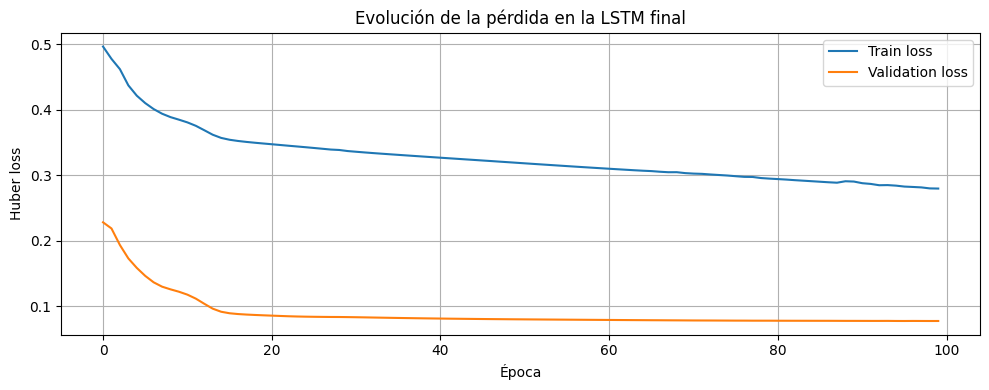

In [ ]:
# Crear una figura para representar la evolución de la pérdida
plt.figure(figsize=(10, 4))  # Tamaño de la figura

# Representar la pérdida de entrenamiento
plt.plot(history_lstm_final.history["loss"], label="Train loss")  # Curva de pérdida de entrenamiento

# Representar la pérdida de validación
plt.plot(history_lstm_final.history["val_loss"], label="Validation loss")  # Curva de pérdida de validación

# Añadir título y etiquetas
plt.title("Evolución de la pérdida en la LSTM final")  # Título del gráfico
plt.xlabel("Época")  # Etiqueta del eje X
plt.ylabel("Huber loss")  # Etiqueta del eje Y

# Añadir leyenda
plt.legend()  # Mostrar leyenda

# Ajustar el diseño
plt.tight_layout()  # Ajustar márgenes automáticamente

# Mostrar figura
plt.show()  # Renderizar gráfico

**Predicciones sobre validation y test y desescalado**

En esta celda se generan las predicciones del modelo final sobre los conjuntos de validación y test. Como el modelo ha sido entrenado sobre datos escalados, tanto las predicciones como los valores reales deben volver a transformarse a la escala original de la serie, es decir, a MWh. Esto es fundamental para obtener métricas interpretables y comparables con el resto de modelos del trabajo.

In [ ]:
# Generar predicciones sobre validation
y_val_pred_scaled = modelo_lstm_final.predict(X_val_best, verbose=0)  # Predicciones escaladas en validation

# Generar predicciones sobre test
y_test_pred_scaled = modelo_lstm_final.predict(X_test_best, verbose=0)  # Predicciones escaladas en test

# Desescalar predicciones de validation
y_val_pred = scaler.inverse_transform(y_val_pred_scaled)  # Predicciones de validation en MWh

# Desescalar predicciones de test
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)  # Predicciones de test en MWh

# Desescalar valores reales de validation
y_val_real = scaler.inverse_transform(y_val_best)  # Valores reales de validation en MWh

# Desescalar valores reales de test
y_test_real = scaler.inverse_transform(y_test_best)  # Valores reales de test en MWh

**Cálculo de métricas finales del modelo LSTM**

Aquí se calculan las métricas principales del modelo final en la escala original de la serie. Se utiliza MAE como métrica principal, porque expresa el error medio absoluto en MWh y es muy interpretable, y RMSE como complemento, porque penaliza más los errores grandes. Estas son las métricas que después utilizarás para comparar la LSTM con la RNN, el naïve, ARIMA y las demás arquitecturas.

In [ ]:
# Calcular MAE en validation
mae_val_final = mean_absolute_error(y_val_real, y_val_pred)  # Error absoluto medio en validation

# Calcular RMSE en validation
rmse_val_final = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Raíz del error cuadrático medio en validation

# Calcular MAE en test
mae_test_final = mean_absolute_error(y_test_real, y_test_pred)  # Error absoluto medio en test

# Calcular RMSE en test
rmse_test_final = np.sqrt(mean_squared_error(y_test_real, y_test_pred))  # Raíz del error cuadrático medio en test

# Mostrar resultados
print("Resultados finales del modelo LSTM")  # Título informativo
print(f"MAE validation:  {mae_val_final:.3f} MWh")  # Mostrar MAE de validation
print(f"RMSE validation: {rmse_val_final:.3f} MWh")  # Mostrar RMSE de validation
print(f"MAE test:        {mae_test_final:.3f} MWh")  # Mostrar MAE de test
print(f"RMSE test:       {rmse_test_final:.3f} MWh")  # Mostrar RMSE de test

Resultados finales del modelo LSTM
MAE validation:  6.201 MWh
RMSE validation: 7.980 MWh
MAE test:        6.128 MWh
RMSE test:       7.973 MWh


**Comparación gráfica entre valores reales y predichos en test**

Este gráfico te permite evaluar visualmente hasta qué punto la LSTM es capaz de seguir la trayectoria real de la serie en el conjunto de test. Es especialmente útil para observar si el modelo reproduce la tendencia general, la estructura semanal y el grado de suavización de picos o cambios bruscos. Esta figura te servirá luego para redactar la interpretación cualitativa del comportamiento predictivo del modelo.

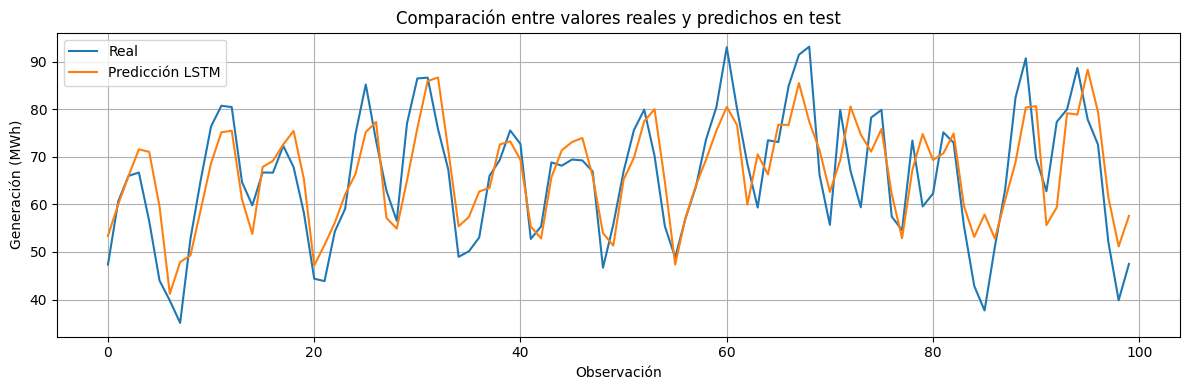

In [ ]:
# Definir cuántos puntos se van a mostrar en la gráfica
n_mostrar = 100  # Número de observaciones del test a representar

# Crear la figura
plt.figure(figsize=(12, 4))  # Tamaño de la figura

# Representar valores reales del test
plt.plot(y_test_real[:n_mostrar], label="Real")  # Serie observada

# Representar predicciones del test
plt.plot(y_test_pred[:n_mostrar], label="Predicción LSTM")  # Serie predicha por la LSTM

# Añadir título y etiquetas
plt.title("Comparación entre valores reales y predichos en test")  # Título del gráfico
plt.xlabel("Observación")  # Etiqueta del eje X
plt.ylabel("Generación (MWh)")  # Etiqueta del eje Y

# Añadir leyenda
plt.legend()  # Mostrar leyenda

# Ajustar el diseño
plt.tight_layout()  # Ajustar márgenes automáticamente

# Mostrar figura
plt.show()  # Renderizar gráfico

**Tabla resumen con las 5 mejores combinaciones**

En esta celda final se construye una tabla limpia con las cinco mejores combinaciones de hiperparámetros obtenidas durante la búsqueda aleatoria. Esta tabla resume de forma clara qué configuraciones han funcionado mejor y con qué métricas lo han hecho. Luego podrás reutilizarla directamente para documentar la selección del modelo LSTM en el TFG.

In [ ]:
# Crear una copia de la tabla top 5 para dejarla más limpia
tabla_top5_lstm = top5_lstm.copy()  # Copia independiente de la tabla ordenada

# Redondear métricas para facilitar la lectura
tabla_top5_lstm["val_mae"] = tabla_top5_lstm["val_mae"].round(3)  # Redondear MAE
tabla_top5_lstm["val_rmse"] = tabla_top5_lstm["val_rmse"].round(3)  # Redondear RMSE

# Renombrar columnas para que la tabla sea más clara
tabla_top5_lstm = tabla_top5_lstm.rename(columns={
    "window_size": "Window size",  # Renombrar columna window_size
    "units": "Units",  # Renombrar columna units
    "batch_size": "Batch size",  # Renombrar columna batch_size
    "dropout": "Dropout",  # Renombrar columna dropout
    "epochs_trained": "Epochs trained",  # Renombrar columna epochs_trained
    "val_mae": "Validation MAE",  # Renombrar columna val_mae
    "val_rmse": "Validation RMSE"  # Renombrar columna val_rmse
})

# Mostrar la tabla final
print("Tabla resumen con las 5 mejores combinaciones de hiperparámetros para la LSTM:\n")  # Título informativo
print(tabla_top5_lstm)  # Mostrar tabla final

# Si quieres verla con formato de DataFrame en Colab/Jupyter, deja esta línea al final
tabla_top5_lstm  # Mostrar tabla con formato enriquecido

Tabla resumen con las 5 mejores combinaciones de hiperparámetros para la LSTM:

   Window size  Units  Batch size  Dropout  Epochs trained  Validation MAE  \
0           21     16          32      0.0             100           6.090   
1           28      8           8      0.0              47           6.115   
2           28     16          16      0.1              78           6.132   
3           21     16           8      0.1              51           6.141   
4           21     16          32      0.2              67           6.280   

   Validation RMSE  
0            7.819  
1            7.868  
2            7.888  
3            7.899  
4            8.076  


,Window size,Units,Batch size,Dropout,Epochs trained,Validation MAE,Validation RMSE
0,21,16,32,0.0,100,6.090,7.819
1,28,8,8,0.0,47,6.115,7.868
2,28,16,16,0.1,78,6.132,7.888
3,21,16,8,0.1,51,6.141,7.899
4,21,16,32,0.2,67,6.280,8.076


**Gráfico final amplio de predicciones en train y test**

Este último bloque replica el estilo de visualización final que ya usaste en la RNN. La idea es representar conjuntamente los valores reales y predichos en entrenamiento y test, para observar de manera más completa cómo se comporta el modelo en ambos tramos. No es imprescindible para calcular métricas, pero sí muy útil para análisis visual, comparación entre arquitecturas y posible inclusión en anexos o material de apoyo del TFG.

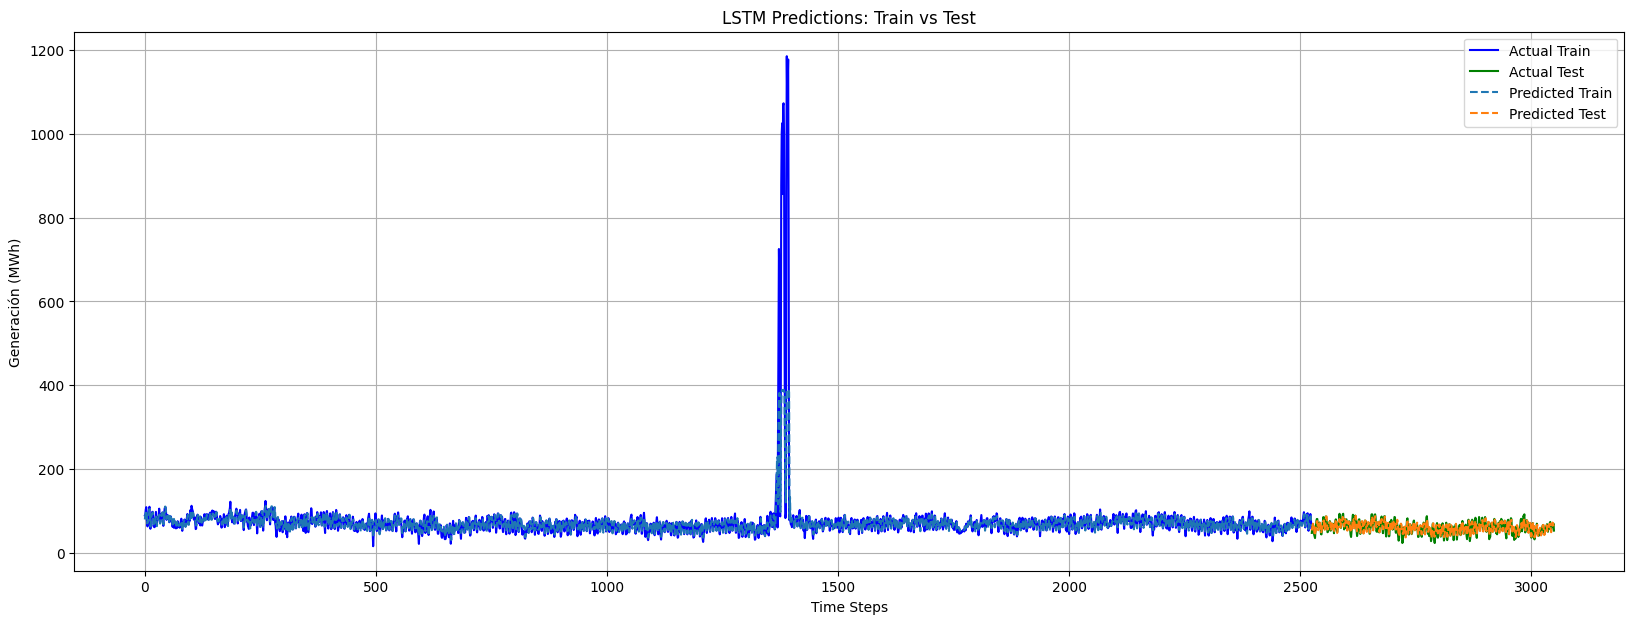

In [ ]:
# Generar predicciones sobre train
y_train_pred_scaled = modelo_lstm_final.predict(X_train_best, verbose=0)  # Predicciones de train en escala escalada

# Generar predicciones sobre test
y_test_pred_scaled = modelo_lstm_final.predict(X_test_best, verbose=0)  # Predicciones de test en escala escalada

# Convertir predicciones de train a valores reales
y_train_pred = scaler.inverse_transform(y_train_pred_scaled)  # Predicciones de train en MWh

# Convertir predicciones de test a valores reales
y_test_pred = scaler.inverse_transform(y_test_pred_scaled)  # Predicciones de test en MWh

# Convertir valores reales de train
y_train_real = scaler.inverse_transform(y_train_best)  # Valores reales de train en MWh

# Convertir valores reales de test
y_test_real = scaler.inverse_transform(y_test_best)  # Valores reales de test en MWh

# Crear eje temporal para train
train_time_steps = range(len(y_train_real))  # Índices temporales de train

# Crear eje temporal para test como continuación de train
test_time_steps = range(len(y_train_real), len(y_train_real) + len(y_test_real))  # Índices temporales de test

# Crear figura grande para mejor visualización
plt.figure(figsize=(20, 7))  # Tamaño grande de la figura

# Representar serie real de entrenamiento
plt.plot(train_time_steps, y_train_real, label="Actual Train", color="blue")  # Línea real de train

# Representar serie real de test
plt.plot(test_time_steps, y_test_real, label="Actual Test", color="green")  # Línea real de test

# Representar predicción en entrenamiento
plt.plot(train_time_steps, y_train_pred, label="Predicted Train", linestyle="--")  # Línea predicha de train

# Representar predicción en test
plt.plot(test_time_steps, y_test_pred, label="Predicted Test", linestyle="--")  # Línea predicha de test

# Personalizar gráfico
plt.title("LSTM Predictions: Train vs Test")  # Título del gráfico
plt.xlabel("Time Steps")  # Etiqueta del eje X
plt.ylabel("Generación (MWh)")  # Etiqueta del eje Y
plt.legend()  # Mostrar leyenda
plt.grid(True)  # Activar cuadrícula

# Mostrar gráfico
plt.show()  # Renderizar la figura

**Cálculo de métricas en el conjunto de entrenamiento**

Para complementar el análisis del rendimiento del modelo dentro y fuera de muestra, se calculan también las métricas MAE y RMSE sobre el conjunto de entrenamiento. Se utilizan las predicciones ya generadas en bloques anteriores, desescaladas a MWh, lo que permite comparar de forma homogénea los errores en train, validation y test.

In [ ]:
# Calcular MAE en train
mae_train_final = mean_absolute_error(y_train_real, y_train_pred)  # Error absoluto medio en train

# Calcular RMSE en train
rmse_train_final = np.sqrt(mean_squared_error(y_train_real, y_train_pred))  # Raíz del error cuadrático medio en train

# Mostrar título de resultados
print("Métricas del modelo LSTM en train")

# Mostrar MAE de train
print(f"MAE train:  {mae_train_final:.3f} MWh")

# Mostrar RMSE de train
print(f"RMSE train: {rmse_train_final:.3f} MWh")

Métricas del modelo LSTM en train
MAE train:  10.321 MWh
RMSE train: 49.009 MWh


**Evolución del MAE en entrenamiento y validación**

Para completar el análisis del entrenamiento del modelo LSTM final se representa la evolución del MAE a lo largo de las épocas, comparando el comportamiento del modelo en el conjunto de entrenamiento y en el de validación. A diferencia de la curva de pérdida Huber mostrada anteriormente, aquí el error se expresa directamente en MWh, lo que facilita su interpretación en el dominio de la generación eléctrica. Esta visualización permite valorar la velocidad de convergencia, la estabilidad del entrenamiento y la posible aparición de sobreajuste a través de la separación entre ambas curvas.

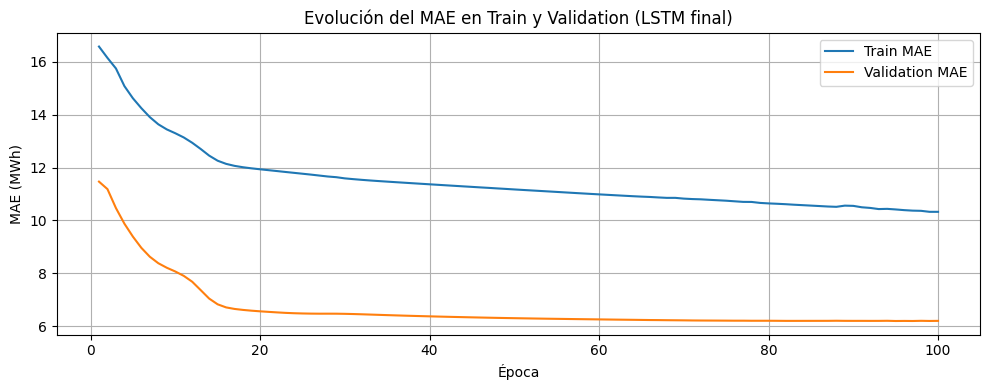

In [ ]:
# Recuperar el factor de escala del RobustScaler para expresar el MAE en MWh
iqr_factor = scaler.scale_[0]                                             # Factor de escala (IQR) usado por RobustScaler

# Convertir el MAE de train por época a la escala original (MWh)
train_mae_mwh = [m * iqr_factor for m in history_lstm_final.history["mae"]]     # MAE de train por época en MWh

# Convertir el MAE de validation por época a la escala original (MWh)
val_mae_mwh = [m * iqr_factor for m in history_lstm_final.history["val_mae"]]   # MAE de validación por época en MWh

# Construir un eje de épocas común
epochs_axis = range(1, len(train_mae_mwh) + 1)                            # Eje de épocas comenzando en 1

# Crear figura
plt.figure(figsize=(10, 4))                                               # Tamaño de la figura

# Representar la curva de MAE en entrenamiento
plt.plot(epochs_axis, train_mae_mwh, label="Train MAE")                   # Curva de MAE de train en MWh

# Representar la curva de MAE en validación
plt.plot(epochs_axis, val_mae_mwh, label="Validation MAE")                # Curva de MAE de validación en MWh

# Añadir título y etiquetas
plt.title("Evolución del MAE en Train y Validation (LSTM final)")         # Título del gráfico
plt.xlabel("Época")                                                       # Etiqueta del eje X
plt.ylabel("MAE (MWh)")                                                   # Etiqueta del eje Y

# Añadir leyenda y ajustar diseño
plt.legend()                                                              # Mostrar leyenda
plt.tight_layout()                                                        # Ajustar márgenes automáticamente

# Mostrar figura
plt.show()                                                                # Renderizar gráfico